## Analiza regresji cen nieruchomości na podstawie danych z Bostonu

## Wybór zbioru danych

Do przeprowadzenia analizy regresji wybrano zbiór danych **Boston Housing Dataset**, który zawiera informacje dotyczące warunków mieszkaniowych w różnych dzielnicach Bostonu. Dane te są często wykorzystywane w zadaniach regresyjnych i eksploracyjnych analizach danych.

### Opis zbioru danych:

- **Liczba obserwacji:** 506
- **Liczba zmiennych:** 14

Zbiór zawiera 14 zmiennych, w tym:

- **Zmienna objaśniana (ilościowa):**
  - `MEDV` – medianowa wartość domów (w tysiącach dolarów)

- **Zmienne objaśniające (ilościowe):**
  - `CRIM` – przestępczość na mieszkańca
  - `ZN` – procent terenów mieszkaniowych przeznaczonych pod działki większe niż 25,000 stóp kwadratowych
  - `INDUS` – procent terenów niekomercyjnych dla biznesu
  - `NOX` – stężenie tlenków azotu
  - `RM` – średnia liczba pokoi w jednostce mieszkalnej
  - `AGE` – procent jednostek wybudowanych przed 1940 rokiem
  - `DIS` – odległość do pięciu głównych centrów zatrudnienia w Bostonie
  - `RAD` – indeks dostępności do autostrad
  - `TAX` – stawka podatku od nieruchomości
  - `PTRATIO` – stosunek liczby uczniów do nauczycieli w szkołach
  - `B` – współczynnik związany z udziałem ludności czarnoskórej
  - `LSTAT` – procent ludności o niskim statusie ekonomicznym

- **Zmienna jakościowa (kategoryczna):**
  - `CHAS` – zmienna binarna informująca o położeniu względem rzeki Charles (1 – tak, 0 – nie)

### Najważniejsze zmienne:
- `MEDV` – medianowa wartość domów (zmienna objaśniana, ilościowa)
- `RM` – średnia liczba pokoi w domu
- `LSTAT` – procent populacji o niskim statusie ekonomicznym
- `CRIM` – przestępczość na mieszkańca
- `NOX` – stężenie tlenków azotu
- `CHAS` – zmienna binarna określająca, czy dzielnica przylega do rzeki Charles (jakościowa)


### Temat i cel analizy

**Temat:** *Wpływ cech nieruchomości na ich cenę – analiza regresji liniowej na przykładzie danych z Bostonu*

**Cel:** Zbudować model regresji liniowej przewidujący cenę nieruchomości (`MEDV`) na podstawie wybranych zmiennych i zidentyfikować najważniejsze czynniki wpływające na cenę.

**Pytanie badawcze:** *Które cechy nieruchomości (np. liczba pokoi, poziom przestępczości, położenie względem rzeki) mają istotny wpływ na cenę domu i w jakim stopniu?*




In [1]:
# Importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Wczyt dane
df = pd.read_csv('/content/boston.csv')
df.head()



,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### Zmienna zależna
W analizie zmienną zależną (objaśnianą) jest:

- `MEDV` – **mediana wartości nieruchomości** wyrażona w tysiącach dolarów.

To zmienna ilościowa, której przewidywaniem zajmuje się stworzony model regresji.

### Przygotowanie danych do analizy

W ramach przygotowania danych do analizy wykonano następujące kroki:

1. **Sprawdzenie braków danych:** Zbadano, czy w zbiorze występują brakujące wartości – nie stwierdzono braków danych, więc nie była konieczna imputacja.
2. **Kodowanie zmiennej jakościowej:** Kolumna `CHAS` jest zmienną jakościową binarną (0 = brak dostępu do rzeki Charles, 1 = dostęp). Zmienna ta została zachowana w formie numerycznej, ponieważ jej wartości są już zakodowane binarnie.
3. **Standaryzacja zmiennych:** W celu zapewnienia porównywalności między zmiennymi i poprawy działania modelu regresji, dane zostały standaryzowane (średnia = 0, odchylenie standardowe = 1) z wykorzystaniem `StandardScaler` z biblioteki `scikit-learn`.
4. **Podział danych:** Dane zostały podzielone na zbiór treningowy i testowy w proporcji 80:20 w celu oceny jakości modelu regresji na danych niewidzianych wcześniej przez model.


In [2]:
# Sprawdzenie braków danych
print("Braki danych w kolumnach:")
print(df.isnull().sum())

# Wyodrębnienie zmiennej zależnej i niezależnych
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

# Kodowanie zmiennej jakościowej nie jest potrzebne – 'CHAS' już jest binarna

# Standaryzacja zmiennych niezależnych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


Braki danych w kolumnach:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


### Statystyki opisowe zmiennej `MEDV`

Wartości zmiennej `MEDV` (ceny mieszkań w tys. dolarów) wahają się od **5.0** do **50.0**.  
Średnia cena wynosi **22.53**, a mediana **21.2**, co sugeruje lekką prawostronną asymetrię rozkładu.  
Odchylenie standardowe wynosi **ok. 9.2**, co wskazuje na **dużą zmienność cen mieszkań**.  
Rozstęp międzykwartylowy (IQR) wynosi **ok. 8.0** (25% = 17.03, 75% = 25.0), co potwierdza zróżnicowanie cen w badanym obszarze.

Dane nie zawierają wartości odstających ekstremalnych, ale **górna granica 50.0 może wskazywać na efekt ucięcia (ang. ceiling effect)** w oryginalnym zbiorze.


In [3]:
df['MEDV'].describe()

,MEDV
count,506.000000
mean,22.532806
std,9.197104
min,5.000000
25%,17.025000
50%,21.200000
75%,25.000000
max,50.000000


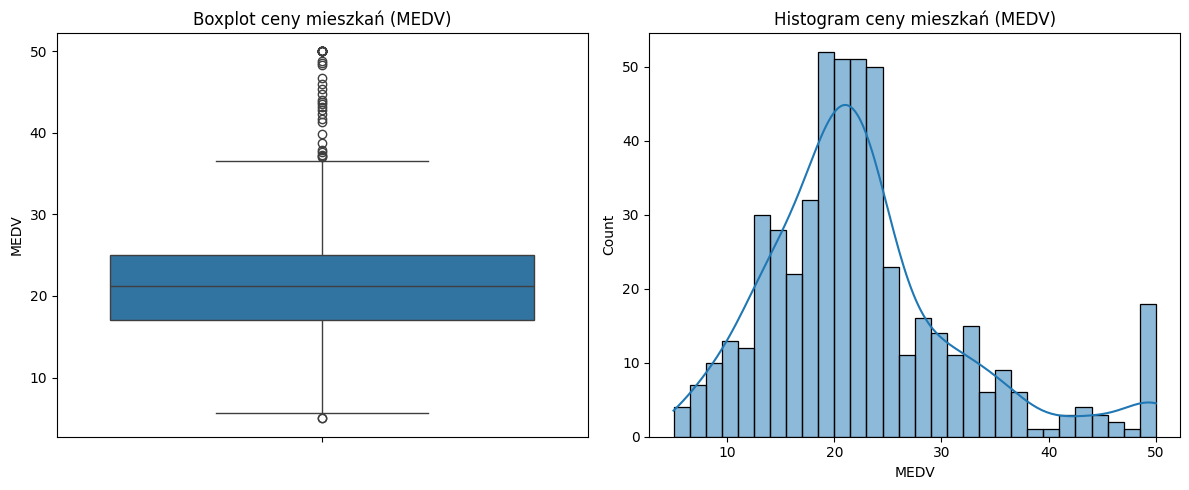

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='MEDV')
plt.title('Boxplot ceny mieszkań (MEDV)')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='MEDV', bins=30, kde=True)
plt.title('Histogram ceny mieszkań (MEDV)')

plt.tight_layout()
plt.show()


### Wnioski z wykresów `MEDV`
- Histogram sugeruje **lekkie prawostronne skośności** – większość cen skupiona jest poniżej 30.
- Boxplot pokazuje **obecność wartości odstających** (outliers), szczególnie powyżej 40.




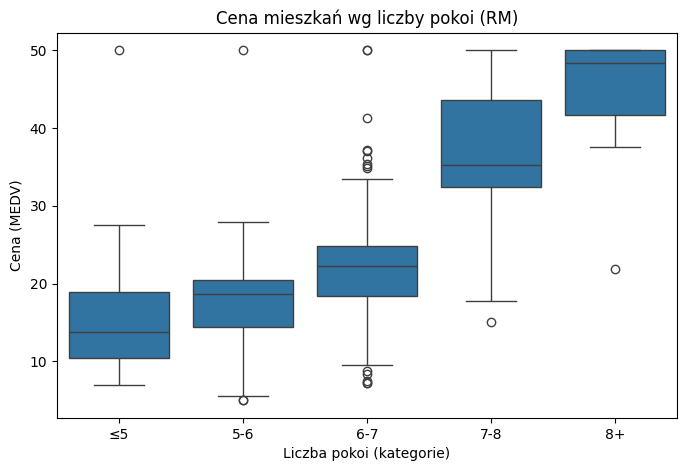

In [5]:
df['RM_category'] = pd.cut(df['RM'], bins=[0, 5, 6, 7, 8, 10], labels=['≤5', '5-6', '6-7', '7-8', '8+'])

plt.figure(figsize=(8,5))
sns.boxplot(x='RM_category', y='MEDV', data=df)
plt.title('Cena mieszkań wg liczby pokoi (RM)')
plt.xlabel('Liczba pokoi (kategorie)')
plt.ylabel('Cena (MEDV)')
plt.show()


<ipython-input-6-c85aa672f765>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Liczba pokoi (kategorie)')


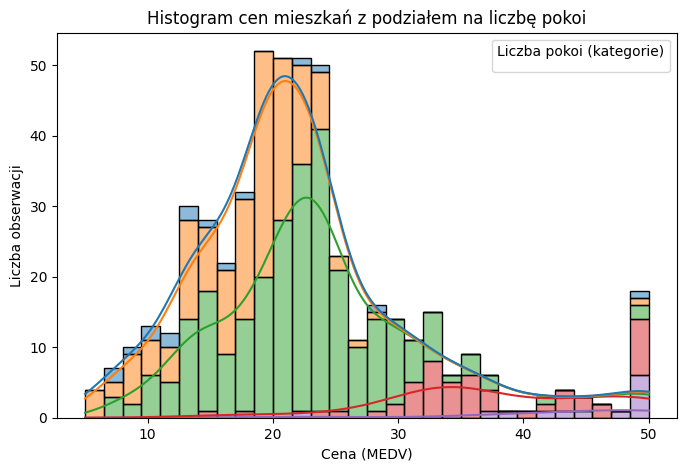

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MEDV', hue='RM_category', bins=30, kde=True, multiple='stack')
plt.title('Histogram cen mieszkań z podziałem na liczbę pokoi')
plt.xlabel('Cena (MEDV)')
plt.ylabel('Liczba obserwacji')
plt.legend(title='Liczba pokoi (kategorie)')
plt.show()


### Wpływ liczby pokoi na cenę (`MEDV`)
Widać wyraźną zależność: im więcej pokoi (`RM`), tym wyższa mediana ceny. Grupa "8+" ma najwyższe ceny, natomiast nieruchomości z 5 pokojami i mniej mają najniższe ceny.


Histogram pokazuje, że największe ceny nieruchomości występują w grupie "8+" pokoi, a najniższe w grupie "≤5".


## Test normalności zmiennej zależnej (`MEDV`)

Celem tego testu jest sprawdzenie, czy zmienna zależna (`MEDV`) ma rozkład normalny – co jest jednym z klasycznych założeń regresji liniowej.

Do weryfikacji użyto testu Shapiro-Wilka, który bada zgodność rozkładu danych z rozkładem normalnym.



In [7]:
from scipy.stats import shapiro

stat, p = shapiro(df['MEDV'])
print(f"Statystyka testu: {stat:.4f}, p-value: {p:.4f}")

if p > 0.05:
    print("MEDV wygląda na zgodne z rozkładem normalnym.")
else:
    print("MEDV nie ma rozkładu normalnego.")


Statystyka testu: 0.9172, p-value: 0.0000
MEDV nie ma rozkładu normalnego.


### Test normalności zmiennej `MEDV`
Wartość p < 0.05 → **odrzucamy hipotezę o normalności rozkładu**. Zmienna `MEDV` nie ma rozkładu normalnego, więc warto o tym pamiętać przy interpretacji wyników.


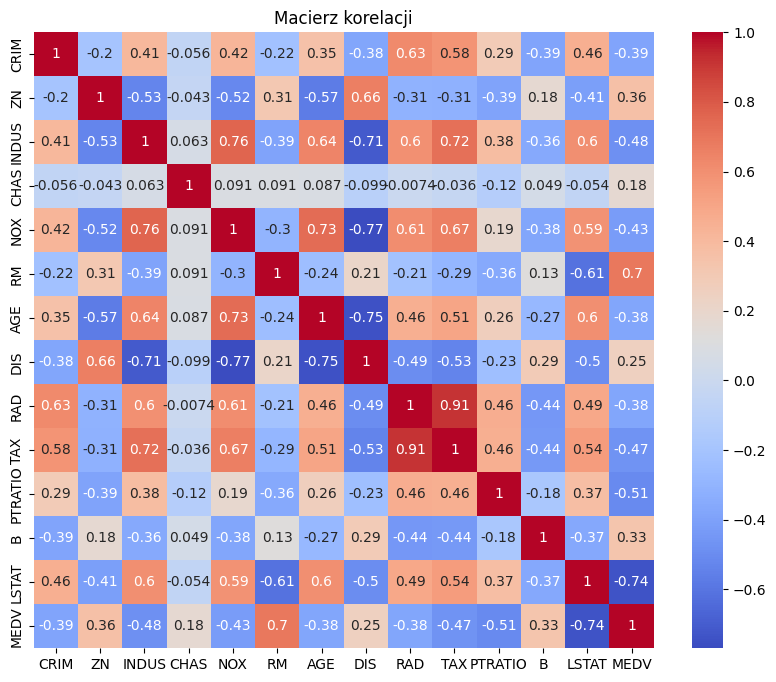

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Macierz korelacji')
plt.show()


### Korelacje między zmiennymi
Najsilniejszą dodatnią korelację z `MEDV` ma `RM` (**+0.7**), natomiast najsilniejszą ujemną `LSTAT` (**–0.74**). Te zmienne wybrano do modelu.
Wysoka liczba pokoi (`RM`) wiąże się ze wzrostem wartości nieruchomości (`MEDV`), co jest intuicyjne – większe domy są droższe.  
Z kolei wyższy udział ludności o niskim statusie społecznym (`LSTAT`) i większe klasy (`PTRATIO`) są skorelowane z niższymi cenami domów.



In [9]:
from sklearn.model_selection import train_test_split

X = df[['RM', 'LSTAT', 'PTRATIO']]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Współczynniki regresji:", model.coef_)
print("Wyraz wolny (intercept):", model.intercept_)


Współczynniki regresji: [ 4.93311836 -0.56712588 -0.86709475]
Wyraz wolny (intercept): 14.58809926157104


### Równanie regresji liniowej
Model regresji:  
`MEDV = 14.59 + 4.93·RM – 0.57·LSTAT – 0.87·PTRATIO`

Model pokazuje, że:
- **każdy dodatkowy pokój** zwiększa przewidywaną cenę o ok. 4.9 tys. USD,
- **wzrost % osób o niskim statusie (`LSTAT`)** obniża cenę,
- **większy stosunek uczniów do nauczycieli (`PTRATIO`)** również obniża cenę.


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R^2: {r2:.2f}")


MSE: 27.11
R^2: 0.63


### Ocena jakości modelu
- **R² ≈ 0.63** – model wyjaśnia ok. 63% zmienności cen mieszkań.
- **MSE ≈ 27.1** – średni błąd prognozy to około 27 (w skali tys. USD).

Model ma **umiarkowaną trafność** – nie idealny, ale przydatny do ogólnych przewidywań.


## Podsumowanie i wnioski

W projekcie przeprowadzono analizę regresji liniowej w celu zbadania, które cechy nieruchomości mają istotny wpływ na ich cenę (`MEDV`).

- Najsilniejszy pozytywny wpływ na cenę ma liczba pokoi (`RM`).  
- Najsilniejszy negatywny wpływ mają:  
- procent osób o niskim statusie społecznym (`LSTAT`)  
- stosunek uczniów do nauczycieli (`PTRATIO`)

Model regresji wielorakiej uzyskał wynik R² = **0.63**, co oznacza, że wyjaśnia on ok. 63% zmienności zmiennej zależnej. Średni błąd prognozy (MSE) to ok. 27 tys. USD.

 **Wnioski końcowe:**  
Cel projektu został osiągnięty – zbudowano model, który na podstawie wybranych cech potrafi przewidywać ceny nieruchomości z rozsądną dokładnością.

